In [2]:
import warnings
warnings.filterwarnings("ignore", message="Workbook contains no default style")

In [3]:
import openpyxl
wb = openpyxl.load_workbook("env_wastrt__custom_21660473_spreadsheet.xlsx", data_only=True)
ws = wb["Data"]

for i, row in enumerate(ws.iter_rows(values_only=True)):
    print(i, row[:5])      # first 5 columns of each row
    if i > 25:             # just the first 26 rows
        break

0 ('Data extracted on 30/05/2026 19:57:20 from [ESTAT]', None, None, None, None)
1 ('Dataset: ', 'Treatment of waste by waste category, hazardousness and waste management operations [env_wastrt__custom_21660473]', None, None, None)
2 ('Last updated: ', '23/09/2025 23:00', None, None, None)
3 (None, None, None, None, None)
4 ('Time frequency', None, 'Annual', None, None)
5 ('Unit of measure', None, 'Tonne', None, None)
6 ('Hazard class', None, 'Hazardous and non-hazardous - total', None, None)
7 ('Waste management operations', None, 'Waste treatment', None, None)
8 ('Waste categories', None, 'Total waste', None, None)
9 (None, None, None, None, None)
10 ('TIME', '2004', None, '2006', None)
11 ('GEO (Labels)', '', '', '', '')
12 ('European Union - 27 countries (from 2020)', 1897000000.0, '', 1932880000.0, '')
13 ('European Union - 28 countries (2013-2020)', 2114190000.0, '', 2174340000.0, '')
14 ('Belgium', 32985766.0, '', 30025212.0, '')
15 ('Bulgaria', 195064838.0, '', 158316294.0, '')

In [4]:
flags = {}
colon = 0
for row in ws.iter_rows(values_only=True):
    for cell in row:
        if cell == ":":
            colon += 1
        elif cell in ("b", "p", "i", "d"):
            flags[cell] = flags.get(cell, 0) + 1
print("':' (missing) count:", colon)
print("flag counts:", flags)

':' (missing) count: 276725
flag counts: {'b': 1922, 'p': 2428, 'i': 196, 'd': 474}


In [14]:
import networkx as nx

# 1. Build the country × 6-route matrix (the "fingerprints")
prof = m[[c+"_pct" for c in cols]].fillna(0)          # rows=countries, 6 columns of %
prof = prof.div(prof.sum(axis=1), axis=0)             # normalize each row to sum to 1

# 2. Cosine similarity between every pair of countries
C  = prof.values
cs = C / np.linalg.norm(C, axis=1, keepdims=True)     # scale each row to length 1
S  = cs @ cs.T                                         # S[i,j] = similarity of country i & j (0..1)

# 3. Connect each country to its K most similar peers (k-nearest-neighbour graph)
countries = list(prof.index)
G = nx.Graph(); G.add_nodes_from(countries)
K = 3
for i in range(len(countries)):
    for j in np.argsort(-S[i])[1:K+1]:                # top-K, skipping itself (the [1:])
        G.add_edge(countries[i], countries[j], weight=float(S[i, j]))

print("nodes:", G.number_of_nodes(), " edges:", G.number_of_edges())

nodes: 27  edges: 53


In [5]:
for i, row in enumerate(ws.iter_rows(values_only=True)):
    if ":" in row:
        print(i, row[:12])
        break

13 ('European Union - 28 countries (2013-2020)', 2114190000.0, '', 2174340000.0, '', 2214610000.0, '', 2230240000.0, '', 2304630000.0, '', 2316560000.0)


In [6]:
import openpyxl, pandas as pd, numpy as np

wb = openpyxl.load_workbook("env_wastrt__custom_21660473_spreadsheet.xlsx", data_only=True)
ws = wb["Data"]

# Rows whose first cell starts with these are NOT country data — skip them.
SKIP = ("Special value","TIME","GEO","Data extracted","Dataset","Last updated",
        "Time frequency","Unit of measure","Hazard class","Waste management","Waste categories")

def first_value(row):           # the label sits in column 3, not 2 — grab first non-empty cell
    for v in row[1:]:
        if v not in (None, ""):
            return v
    return None

def to_year(x):                 # years are stored as TEXT ("2004") — turn into int, or None
    try:    return int(str(x).strip())
    except: return None

records = []
operation = hazard = category = years = None   # "memory" of the last header we passed

for row in ws.iter_rows(values_only=True):
    a = row[0]
    if not isinstance(a, str):
        continue
    # --- header rows: update memory, then move on ---
    if a.startswith("Waste management operations"): operation = first_value(row); continue
    if a.startswith("Hazard class"):                hazard    = first_value(row); continue
    if a.startswith("Waste categories"):            category  = first_value(row); continue
    if a == "TIME":  years = [to_year(x) for x in row[1:] if to_year(x) is not None]; continue
    # --- skip legend / metadata / bare flag letters ---
    a = a.strip()
    if a == "" or any(a.startswith(p) for p in SKIP) or a in (":","b","d","i","p"):
        continue
    if not (operation and hazard and category and years):   # safety: no header seen yet
        continue
    # --- this is a country row: emit one record per year ---
    for k, y in enumerate(years):
        idx = 1 + 2*k                       # value columns are at odd positions 1,3,5,...
        v = row[idx] if idx < len(row) else None
        tonnes = float(v) if isinstance(v, (int, float)) else np.nan   # ":" etc -> NaN
        records.append((a, hazard, operation, category, y, tonnes))

df = pd.DataFrame(records, columns=["country","hazard","operation","category","year","tonnes"])
df.to_csv("waste_tidy.csv", index=False)
print(df.shape)
print("operations:", df.operation.nunique(), "| categories:", df.category.nunique())
df.head()

(527430, 6)
operations: 9 | categories: 46


,country,hazard,operation,category,year,tonnes
0,European Union - 27 countries (from 2020),Hazardous and non-hazardous - total,Waste treatment,Total waste,2004,1.897000e+09
1,European Union - 27 countries (from 2020),Hazardous and non-hazardous - total,Waste treatment,Total waste,2006,1.932880e+09
2,European Union - 27 countries (from 2020),Hazardous and non-hazardous - total,Waste treatment,Total waste,2008,1.949520e+09
3,European Union - 27 countries (from 2020),Hazardous and non-hazardous - total,Waste treatment,Total waste,2010,2.030040e+09
4,European Union - 27 countries (from 2020),Hazardous and non-hazardous - total,Waste treatment,Total waste,2012,2.111800e+09


In [7]:
mask = ((df.country=="Romania") & (df.category=="Total waste") &
        (df.hazard=="Hazardous and non-hazardous - total") &
        (df.operation=="Recovery - recycling") & (df.year==2022))
print(df.loc[mask, "tonnes"].values)   # expect [6994422.]

[6994422.]


In [8]:
df = pd.read_csv("waste_tidy.csv")     # (if starting a fresh session)

TOT   = "Hazardous and non-hazardous - total"
CAT   = "Waste excluding major mineral wastes"   # fairer base: excludes huge inert mineral flows
TOTAL_OP = "Waste treatment"                      # the denominator = all waste treated
EU27 = ["Belgium","Bulgaria","Czechia","Denmark","Germany","Estonia","Ireland","Greece","Spain",
"France","Croatia","Italy","Cyprus","Latvia","Lithuania","Luxembourg","Hungary","Malta",
"Netherlands","Austria","Poland","Portugal","Romania","Slovenia","Slovakia","Finland","Sweden"]

# friendly name -> the exact Eurostat operation label
OPS = {"Recycling":"Recovery - recycling",
       "Energy recovery":"Recovery - energy recovery (R1)",
       "Backfilling":"Recovery - backfilling",
       "Incineration":"Disposal - incineration (D10)",
       "Landfill":"Disposal - landfill (D1, D5, D12)",
       "Other disposal":"Disposal - other (D2-D4, D6-D7)"}
cols = list(OPS)

def mix(cat, year, countries):
    d = df[(df.category==cat) & (df.hazard==TOT) &
           (df.year==year) & (df.country.isin(countries))]
    # pivot: rows = countries, columns = operations, cells = tonnes
    p = d.pivot_table(index="country", columns="operation", values="tonnes", aggfunc="first")
    out = pd.DataFrame(index=p.index)
    out["Total"] = p.get(TOTAL_OP)
    for name, op in OPS.items():
        out[name] = p.get(op)
        out[name+"_pct"] = 100 * out[name] / out["Total"]   # share of all treated waste
    return out

m = mix(CAT, 2022, EU27).dropna(subset=["Total"])
print(m[[c+"_pct" for c in cols]].round(1))

             Recycling_pct  Energy recovery_pct  Backfilling_pct  \
country                                                            
Austria               65.2                  NaN              1.4   
Belgium               80.2                 14.5              0.0   
Bulgaria              23.4                  3.4              0.0   
Croatia               67.3                  3.3              0.6   
Cyprus                62.7                 15.5              0.0   
Czechia               55.0                 11.6              1.7   
Denmark               52.7                 43.7              2.4   
Estonia               10.3                  3.9              0.5   
Finland               41.7                 46.7              1.6   
France                47.5                 26.9              0.0   
Germany               53.7                  NaN              3.6   
Greece                42.0                  6.1              0.0   
Hungary               30.5                  8.9 

In [9]:
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi":120, "font.size":11,
                     "axes.spines.top":False, "axes.spines.right":False,
                     "axes.grid":True, "grid.alpha":.25})
ACC = "#1b7837"   # green
RO  = "#d6604d"   # red, to highlight Romania

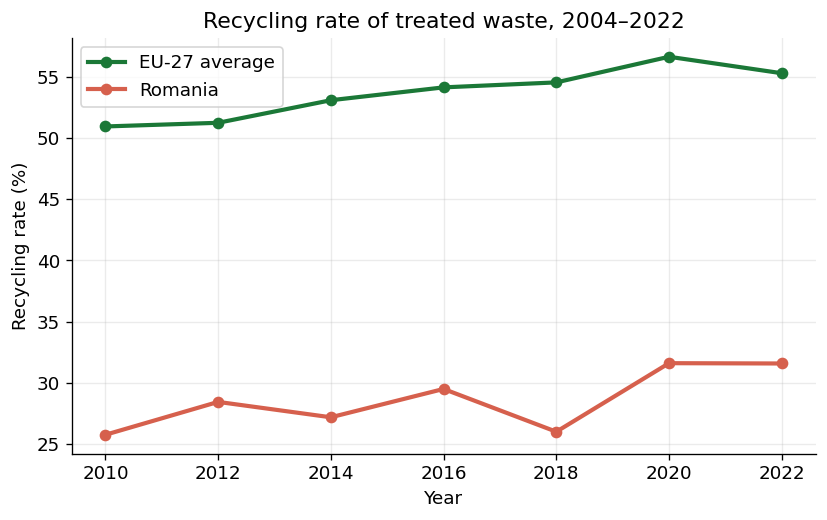

In [10]:
years = sorted(df.year.unique())

def rate_series(country):                 # recycling rate for one country, across all years
    out = []
    for y in years:
        d   = df[(df.category==CAT) & (df.hazard==TOT) & (df.year==y) & (df.country==country)]
        rec = d[d.operation==OPS["Recycling"]].tonnes.sum()
        tot = d[d.operation==TOTAL_OP].tonnes.sum()
        out.append(100*rec/tot if tot>0 else np.nan)
    return out

ro = rate_series("Romania")
eu = rate_series("European Union - 27 countries (from 2020)")

fig, ax = plt.subplots(figsize=(8,4.5))
ax.plot(years, eu, "-o", color=ACC, lw=2.5, label="EU-27 average")
ax.plot(years, ro, "-o", color=RO,  lw=2.5, label="Romania")
ax.set(xlabel="Year", ylabel="Recycling rate (%)",
       title="Recycling rate of treated waste, 2004–2022")
ax.legend()
plt.savefig("fig1_recycling_trend.png",  dpi=200, bbox_inches="tight")
plt.show()

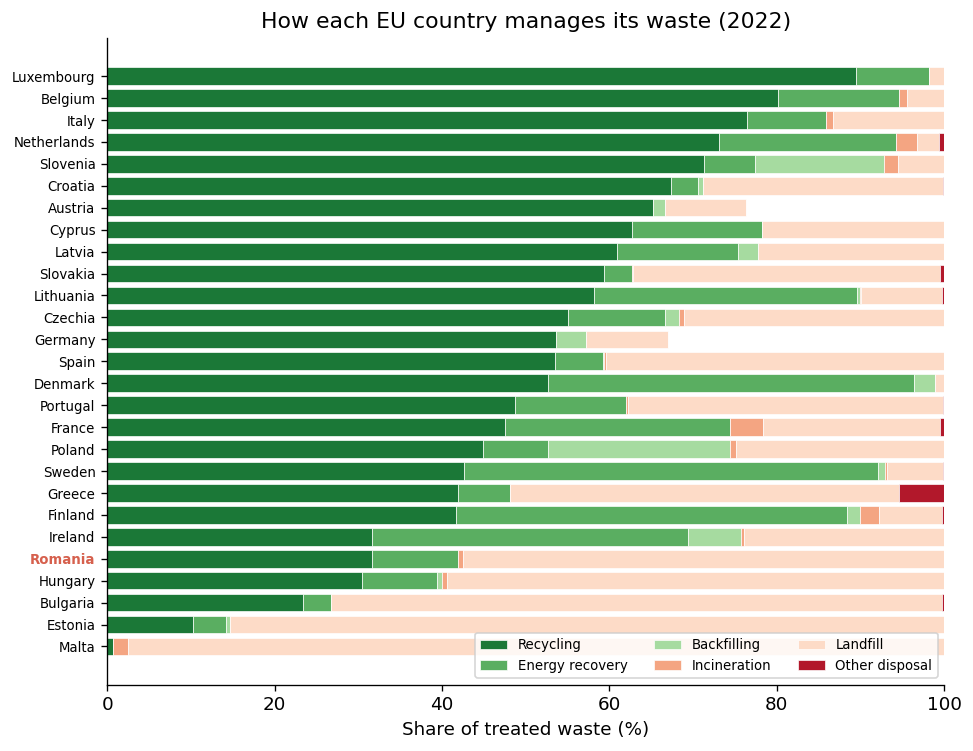

In [11]:
order  = m.sort_values("Recycling_pct").index           # worst recyclers at bottom
colors = ["#1b7837","#5aae61","#a6dba0","#f4a582","#fddbc7","#b2182b"]  # green→red

fig, ax = plt.subplots(figsize=(9,7))
left = np.zeros(len(order))                              # running x-offset for stacking
for c, col in zip(cols, colors):
    vals = m.loc[order, c+"_pct"].fillna(0).values
    ax.barh(range(len(order)), vals, left=left, color=col, label=c, edgecolor="white", lw=.4)
    left += vals                                         # next segment starts where this ends

ax.set_yticks(range(len(order)))
ax.set_yticklabels(order, fontsize=8)
for i, c in enumerate(order):                            # bold + red label for Romania
    if c == "Romania":
        ax.get_yticklabels()[i].set_color(RO)
        ax.get_yticklabels()[i].set_fontweight("bold")
ax.set(xlabel="Share of treated waste (%)", xlim=(0,100),
       title="How each EU country manages its waste (2022)")
ax.legend(ncol=3, fontsize=8, loc="lower right")
ax.grid(False)
plt.savefig("fig2_management_mix.png",    dpi=200, bbox_inches="tight")
plt.show()

mean: 50.9%   std: 20.7   min: Malta 0.7   max: Luxembourg 89.5
Romania: 31.6% — rank 23 of 27


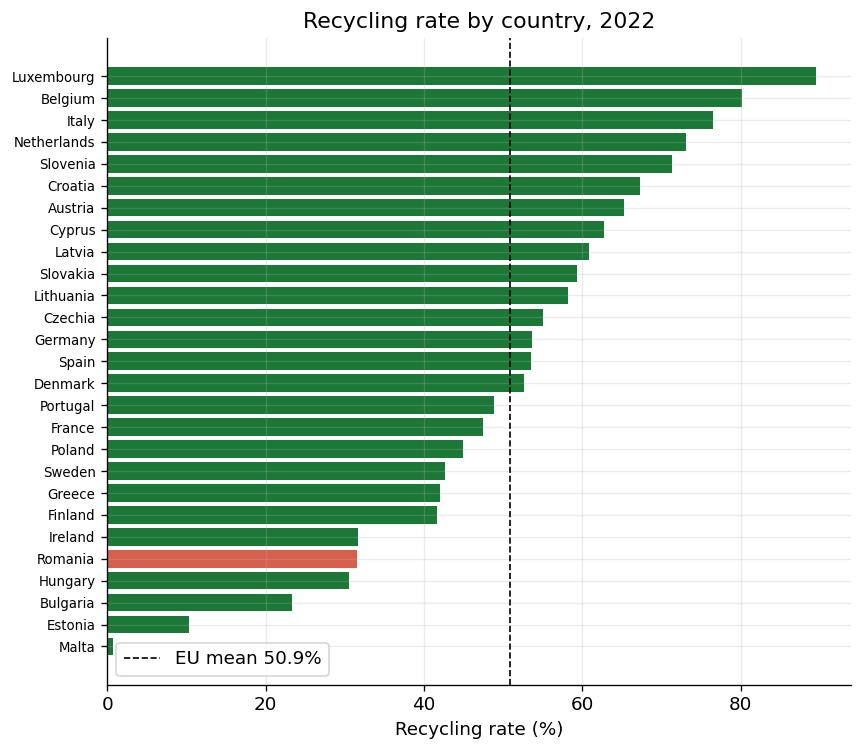

In [12]:
rr = m["Recycling_pct"].sort_values()      # ascending: worst at top of a horizontal bar

print("mean: %.1f%%   std: %.1f   min: %s %.1f   max: %s %.1f"
      % (rr.mean(), rr.std(), rr.idxmin(), rr.min(), rr.idxmax(), rr.max()))
rank = list(rr.index[::-1]).index("Romania") + 1     # 1 = best
print("Romania: %.1f%% — rank %d of 27" % (rr["Romania"], rank))

fig, ax = plt.subplots(figsize=(8,7))
ax.barh(range(len(rr)), rr.values,
        color=[RO if c=="Romania" else ACC for c in rr.index])   # highlight Romania
ax.set_yticks(range(len(rr))); ax.set_yticklabels(rr.index, fontsize=8)
ax.axvline(rr.mean(), color="k", ls="--", lw=1, label=f"EU mean {rr.mean():.1f}%")
ax.set(xlabel="Recycling rate (%)", title="Recycling rate by country, 2022")
ax.legend()
plt.savefig("fig3_recycling_ranking.png", dpi=200, bbox_inches="tight")
plt.show()

Pearson r = -0.816   (p = 2.18e-07)


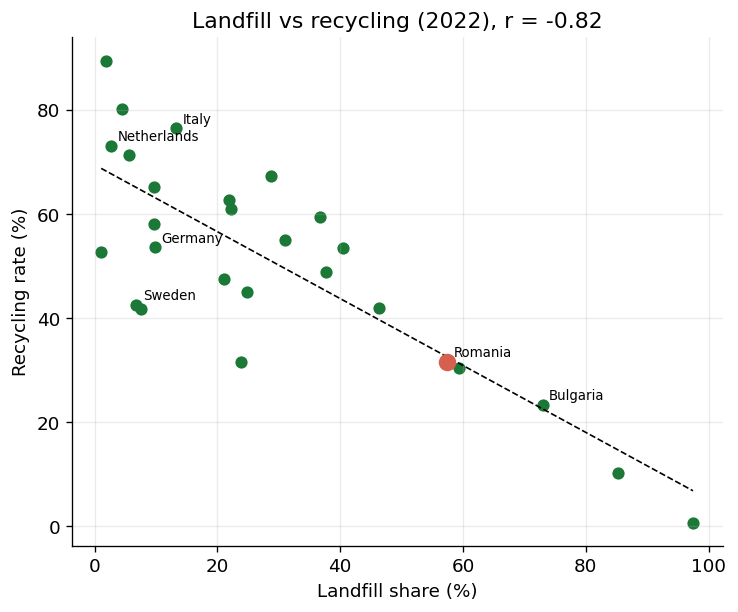

In [13]:
from scipy.stats import pearsonr

x = m["Landfill_pct"].values
y = m["Recycling_pct"].values
mask = ~(np.isnan(x) | np.isnan(y))          # drop any country missing a value
x, y, names = x[mask], y[mask], m.index[mask]

r, p = pearsonr(x, y)
print("Pearson r = %.3f   (p = %.2e)" % (r, p))

fig, ax = plt.subplots(figsize=(7,5.5))
ax.scatter(x, y, color=ACC, s=40)
ri = list(names).index("Romania")            # mark Romania
ax.scatter(x[ri], y[ri], color=RO, s=90, zorder=5)
for xi, yi, n in zip(x, y, names):           # label a few notable countries
    if n in ("Romania","Germany","Sweden","Bulgaria","Italy","Netherlands"):
        ax.annotate(n, (xi, yi), fontsize=8, xytext=(4,3), textcoords="offset points")
b, a = np.polyfit(x, y, 1)                    # best-fit line: slope b, intercept a
xs = np.linspace(x.min(), x.max(), 50)
ax.plot(xs, b*xs + a, "k--", lw=1)
ax.set(xlabel="Landfill share (%)", ylabel="Recycling rate (%)",
       title=f"Landfill vs recycling (2022), r = {r:.2f}")
plt.savefig("fig4_landfill_vs_recycling.png", dpi=200, bbox_inches="tight")
plt.show()

mean 73.4 Mt  std 92.3  max Germany 368  min Latvia 1.8


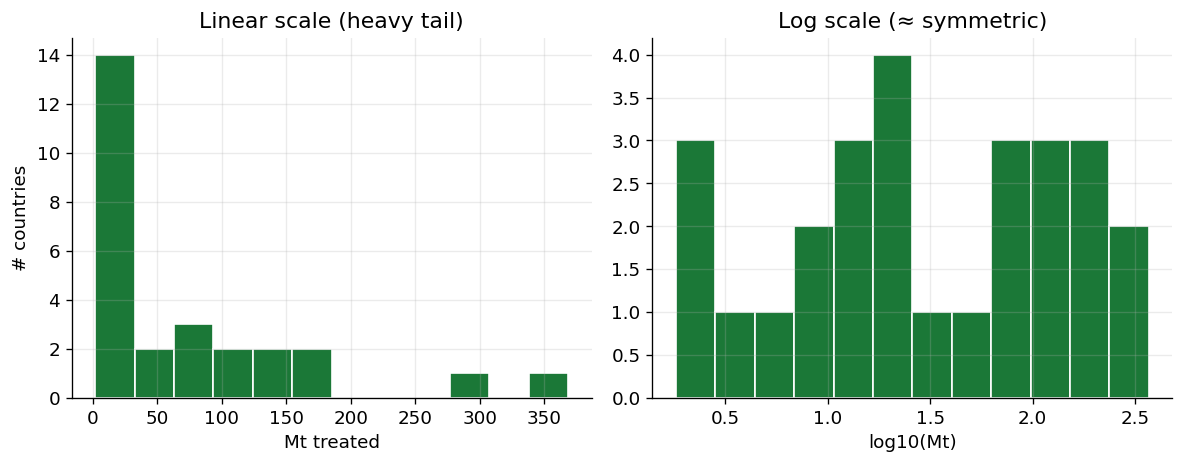

In [16]:
# Total waste treated per country, 2022, in million tonnes
tw = df[(df.category=="Total waste") & (df.hazard==TOT) &
        (df.operation==TOTAL_OP) & (df.year==2022) & (df.country.isin(EU27))]
vals = tw.set_index("country").tonnes.dropna() / 1e6

print("mean %.1f Mt  std %.1f  max %s %.0f  min %s %.1f"
      % (vals.mean(), vals.std(), vals.idxmax(), vals.max(), vals.idxmin(), vals.min()))

fig, ax = plt.subplots(1, 2, figsize=(10,4))
ax[0].hist(vals, bins=12, color=ACC, edgecolor="white")
ax[0].set(xlabel="Mt treated", ylabel="# countries", title="Linear scale (heavy tail)")
ax[1].hist(np.log10(vals), bins=12, color=ACC, edgecolor="white")
ax[1].set(xlabel="log10(Mt)", title="Log scale (≈ symmetric)")
plt.tight_layout()
plt.savefig("fig5_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

In [15]:
# Community detection: groups of countries more linked to each other than to the rest
comms = list(nx.community.greedy_modularity_communities(G, weight="weight"))
cmap  = {n: k for k, com in enumerate(comms) for n in com}   # country -> community id
nx.set_node_attributes(G, cmap, "community")

# Attach node attributes for later (and for Gephi)
nx.set_node_attributes(G, {c: float(m.loc[c,"Recycling_pct"]) for c in countries}, "recycling_pct")
nx.set_node_attributes(G, nx.betweenness_centrality(G), "betweenness")

modularity = nx.community.modularity(G, comms, weight="weight")
print("communities: %d   modularity: %.3f\n" % (len(comms), modularity))
for k, com in enumerate(comms):
    avg = np.mean([m.loc[c,"Recycling_pct"] for c in com])
    print(f"  Community {k} (avg recycling {avg:.0f}%): " + ", ".join(sorted(com)))

# Export for Gephi
nx.write_graphml(G, "country_waste_network.graphml")

communities: 4   modularity: 0.622

  Community 0 (avg recycling 57%): Croatia, Cyprus, Czechia, Latvia, Poland, Portugal, Slovakia, Spain
  Community 1 (avg recycling 73%): Austria, Belgium, Germany, Italy, Luxembourg, Netherlands, Slovenia
  Community 2 (avg recycling 23%): Bulgaria, Estonia, Greece, Hungary, Malta, Romania
  Community 3 (avg recycling 46%): Denmark, Finland, France, Ireland, Lithuania, Sweden


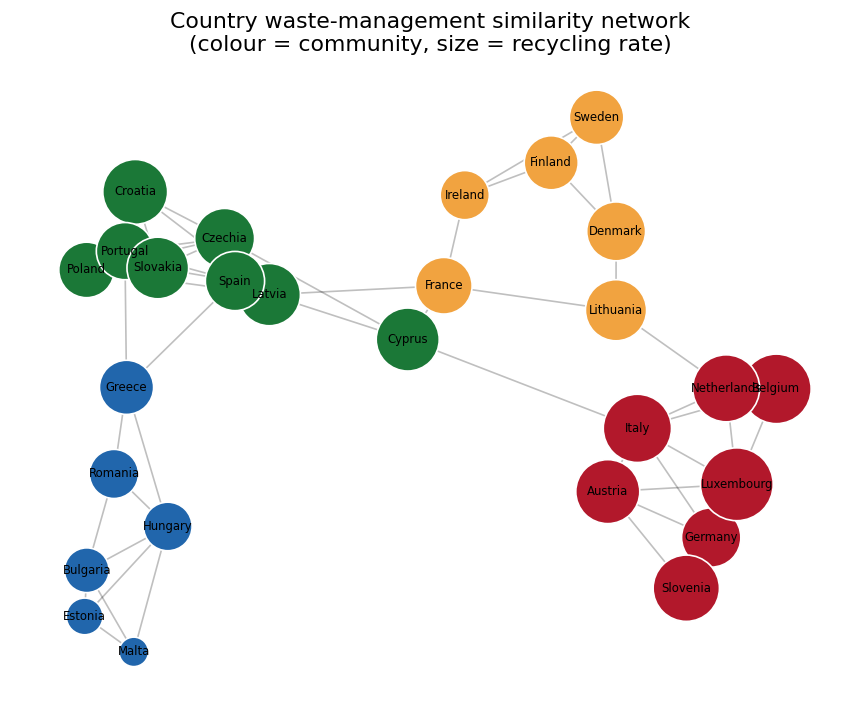

In [17]:
fig, ax = plt.subplots(figsize=(9,7))
pos = nx.spring_layout(G, seed=42, k=.6, weight="weight")   # similar nodes pulled together
pal = ["#1b7837","#b2182b","#2166ac","#f1a340","#762a83"]

nx.draw_networkx_edges(G, pos, alpha=.25, ax=ax)
nx.draw_networkx_nodes(G, pos, ax=ax, edgecolors="white", linewidths=1,
    node_color=[pal[cmap[n] % len(pal)] for n in G],        # colour = community
    node_size=[300 + 18*m.loc[n,"Recycling_pct"] for n in G])  # size = recycling rate
nx.draw_networkx_labels(G, pos, font_size=7, ax=ax)
ax.set_title("Country waste-management similarity network\n(colour = community, size = recycling rate)")
ax.axis("off")
plt.savefig("fig6_network.png",           dpi=200, bbox_inches="tight")
plt.show()

In [18]:
import os
print([f for f in os.listdir() if f.endswith(".png")])

['fig1_recycling_trend.png', 'fig2_management_mix.png', 'fig3_recycling_ranking.png', 'fig4_landfill_vs_recycling.png', 'fig5_distribution.png', 'fig6_network.png', 'screen 1.png', 'screen 10.png', 'screen 11.2.png', 'screen 11.png', 'screen 12.2.png', 'screen 12.png', 'screen 13.2.png', 'screen 13.png', 'screen 14.png', 'screen 15.2.png', 'screen 15.png', 'screen 16.png', 'screen 17.2.png', 'screen 18.1.png', 'screen 18.2.png', 'screen 18.png', 'screen 2.png', 'screen 3.png', 'screen 4.2.png', 'screen 4.png', 'screen 5.1.png', 'screen 5.2.png', 'screen 6.1.png', 'screen 6.2.png', 'screen 7.png', 'screen 8.2.png', 'screen 8.png', 'screen 9.png']


In [20]:
import os
print("Folder:", os.getcwd())
print("Figures:", [f for f in os.listdir() if f.endswith(".png")])

Folder: C:\Users\alexa\OneDrive\Documents\BDV\BDV
Figures: ['fig1_recycling_trend.png', 'fig2_management_mix.png', 'fig3_recycling_ranking.png', 'fig4_landfill_vs_recycling.png', 'fig5_distribution.png', 'fig6_network.png', 'screen 1.png', 'screen 10.png', 'screen 11.2.png', 'screen 11.png', 'screen 12.2.png', 'screen 12.png', 'screen 13.2.png', 'screen 13.png', 'screen 14.png', 'screen 15.2.png', 'screen 15.png', 'screen 16.png', 'screen 17.2.png', 'screen 18.1.png', 'screen 18.2.png', 'screen 18.png', 'screen 2.png', 'screen 3.png', 'screen 4.2.png', 'screen 4.png', 'screen 5.1.png', 'screen 5.2.png', 'screen 6.1.png', 'screen 6.2.png', 'screen 7.png', 'screen 8.2.png', 'screen 8.png', 'screen 9.png']


In [21]:
print("Romania recycling rate by year:")
for y, v in zip(years, ro):
    print(f"  {y}: {v:.1f}%")
print(f"\nFirst→last: {ro[0]:.1f}% → {ro[-1]:.1f}%   (change: {ro[-1]-ro[0]:+.1f} points)")

Romania recycling rate by year:
  2004: nan%
  2006: nan%
  2008: nan%
  2010: 25.8%
  2012: 28.5%
  2014: 27.2%
  2016: 29.5%
  2018: 26.0%
  2020: 31.6%
  2022: 31.6%

First→last: nan% → 31.6%   (change: +nan points)
